In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
from IPython import display

In [2]:
def as_gif(images, path="temp.gif", dur=4):
  # Render the images as the gif (15Hz control frequency):
  images[0].save(path, save_all=True, append_images=images[1:], duration=int(1000/dur), loop=0)
  gif_bytes = open(path,"rb").read()
  return gif_bytes

In [3]:
builder = tfds.builder_from_directory("data")

In [4]:
ds = builder.as_dataset(split="train")

In [5]:
iterator = iter(ds)

In [16]:
episode = next(iterator)

In [17]:
episode['aspects']

{'already_success': <tf.Tensor: shape=(), dtype=bool, numpy=False>,
 'feasible': <tf.Tensor: shape=(), dtype=bool, numpy=False>,
 'has_aspects': <tf.Tensor: shape=(), dtype=bool, numpy=False>,
 'success': <tf.Tensor: shape=(), dtype=bool, numpy=False>,
 'undesirable': <tf.Tensor: shape=(), dtype=bool, numpy=False>}

In [18]:
episode['attributes']

{'collection_mode': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'collection_mode_name': <tf.Tensor: shape=(), dtype=string, numpy=b'UNSPECIFIED_COLLECTION_MODE'>,
 'data_type': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'data_type_name': <tf.Tensor: shape=(), dtype=string, numpy=b'UNSPECIFIED_DATA_TYPE'>,
 'env': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'env_name': <tf.Tensor: shape=(), dtype=string, numpy=b'UNSPECIFIED_ENV_TYPE'>,
 'location': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'location_name': <tf.Tensor: shape=(), dtype=string, numpy=b'UNSPECIFIED_LOCATION'>,
 'objects_family': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'objects_family_name': <tf.Tensor: shape=(), dtype=string, numpy=b'UNSPECIFIED_OBJECTS_FAMILY'>,
 'task_family': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'task_family_name': <tf.Tensor: shape=(), dtype=string, numpy=b'UNSPECIFIED_TASK_FAMILY'>}

In [19]:
episodes = list(episode['steps'])

In [20]:
episodes[0].keys()

dict_keys(['action', 'is_first', 'is_last', 'is_terminal', 'observation', 'reward'])

In [27]:
images = []
for i, step in enumerate(episode["steps"]):
    if i % 1 == 0:

        images.append(
            Image.fromarray(
            np.concatenate((
                    step["observation"]["image"].numpy(),
            ), axis=1)
            )
        )

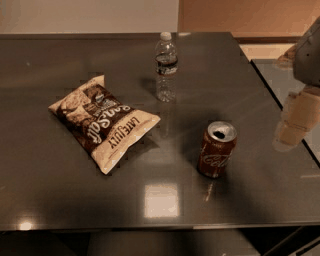

In [28]:
display.Image(as_gif(images, dur=5))

In [26]:
len(episodes)

22

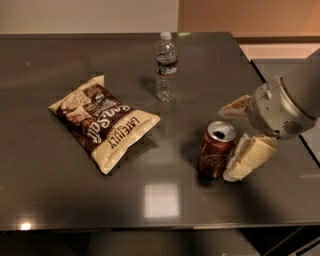

In [43]:
Image.fromarray(episodes[7]["observation"]["image"].numpy())

In [44]:
episodes[6]['action']['gripper_closedness_action']

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.9996527], dtype=float32)>

In [34]:
episodes[13]['observation']['gripper_closed']

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>

In [35]:
episodes[13]['observation']['gripper_closedness_commanded']

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>

In [27]:
import matplotlib.pyplot as plt

local shard count: 1
  data\fractal20220817_data-train.tfrecord-00000-of-01024

world_vector shape: (3369, 3)
min : [-0.6938333  -0.27670512 -0.5030858 ]
max : [0.27967885 0.22378972 0.43312255]
mean: [ 0.00725723  0.00557915 -0.01115399]
std : [0.06995476 0.04727386 0.07125591]

rotation_delta shape: (3369, 3)
min : [-0.97836906 -0.7142117  -0.8839837 ]
max : [1.0189477 0.9490272 1.3339566]
mean: [ 0.04549921 -0.00194761  0.00149477]
std : [0.15790604 0.13594861 0.14526582]

episode count: 80
min   : 15
max   : 115
mean  : 42.1125
median: 40.0
p_05  : 20.95
p_95  : 71.24999999999999


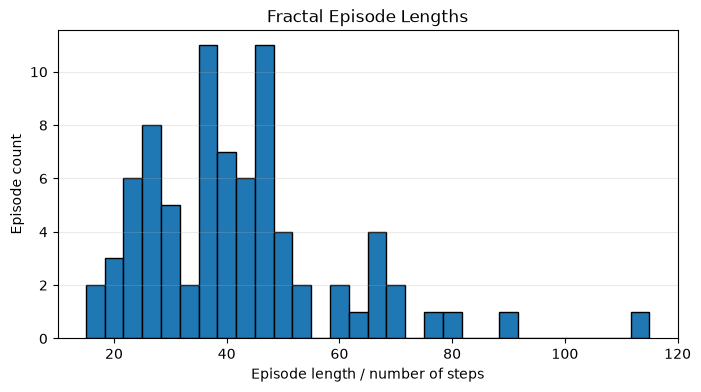

In [28]:
import matplotlib.pyplot as plt
import glob

local_tfrecords = sorted(glob.glob("data/fractal20220817_data-train.tfrecord-*"))
print("local shard count:", len(local_tfrecords))
for path in local_tfrecords:
    print(" ", path)

local_ds = tf.data.TFRecordDataset(local_tfrecords).map(
    builder.info.features.deserialize_example,
    num_parallel_calls=tf.data.AUTOTUNE,
)

world_vectors = []
rotation_deltas = []
episode_lengths = []

for episode_index, episode in enumerate(local_ds):
    steps = list(episode["steps"])
    episode_lengths.append(len(steps))

    for step in steps:
        world_vectors.append(step["action"]["world_vector"].numpy())
        rotation_deltas.append(step["action"]["rotation_delta"].numpy())

world_vectors = np.stack(world_vectors, axis=0)
rotation_deltas = np.stack(rotation_deltas, axis=0)
episode_lengths = np.asarray(episode_lengths, dtype=np.int64)

def print_vector_stats(name, values):
    print(f"\n{name} shape: {values.shape}")
    print("min :", values.min(axis=0))
    print("max :", values.max(axis=0))
    print("mean:", values.mean(axis=0))
    print("std :", values.std(axis=0))

def print_length_stats(lengths):
    print(f"\nepisode count: {len(lengths)}")
    print("min   :", lengths.min())
    print("max   :", lengths.max())
    print("mean  :", lengths.mean())
    print("median:", np.median(lengths))
    print("p_05  :", np.percentile(lengths, 5))
    print("p_95  :", np.percentile(lengths, 95))

print_vector_stats("world_vector", world_vectors)
print_vector_stats("rotation_delta", rotation_deltas)
print_length_stats(episode_lengths)

plt.figure(figsize=(8, 4))
plt.hist(episode_lengths, bins=30, edgecolor="black")
plt.title("Fractal Episode Lengths")
plt.xlabel("Episode length / number of steps")
plt.ylabel("Episode count")
plt.grid(axis="y", alpha=0.25)
plt.show()

episodes checked: 80

action/gripper_closedness_action
  min/max/mean/std: -1.0 1.0 0.023539517 0.36099187
  most common rounded values:
     0.000: 2320
     1.000: 121
    -1.000: 98
     0.010: 18
     0.999: 13
    -0.999: 12
     0.116: 12
     0.020: 11
     0.823: 11
    -0.358: 9
    -0.823: 9
    -0.817: 9

observation/gripper_closed
  min/max/mean/std: 0.0 1.0 0.44686154 0.45350078
  most common rounded values:
     0.000: 1433
     1.000: 1122
     0.460: 17
     0.999: 16
     0.001: 15
     0.177: 12
     0.884: 12
     0.421: 10
     0.370: 9
     0.128: 9
     0.817: 9
     0.413: 9

observation/gripper_closedness_commanded
  min/max/mean/std: -1.0 1.0 0.015557573 0.29502943
  most common rounded values:
     0.000: 2479
     1.000: 48
    -1.000: 38
     0.010: 18
     0.009: 13
     0.116: 12
     0.823: 11
    -0.999: 10
     0.999: 10
    -0.358: 9
    -0.823: 9
    -0.817: 9

Relationship tests, lower RMSE / higher corr is more plausible:
  action[t] vs commanded[t]

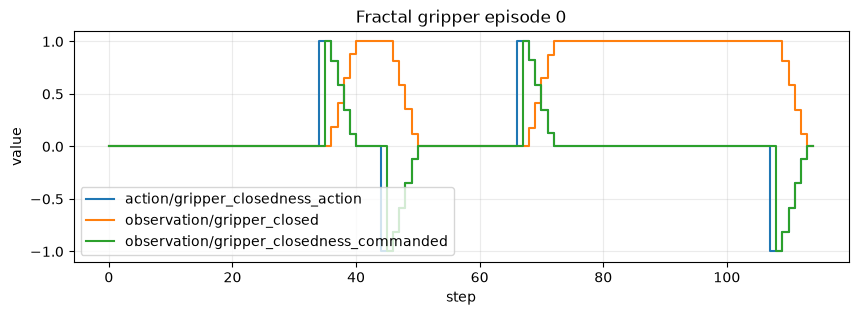

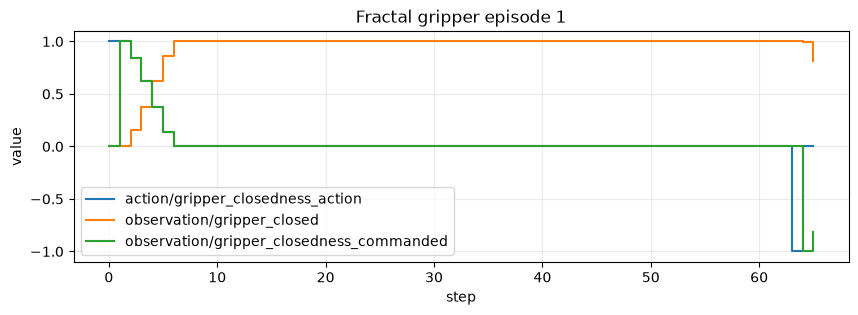

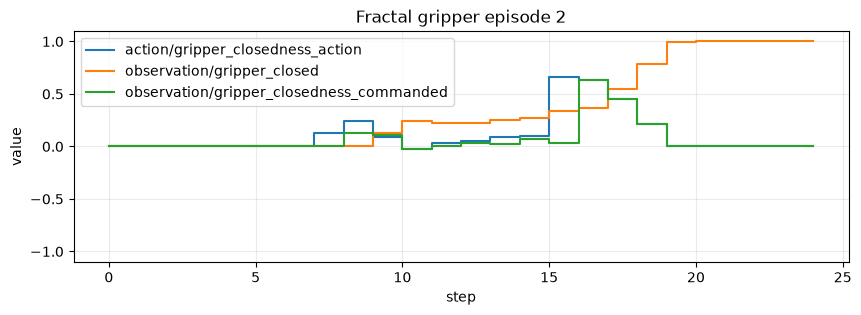


Interpretation hint:
  gripper_closed is the measured/binary-ish state.
  gripper_closedness_commanded is the controller's current continuous gripper target/state.
  gripper_closedness_action is the action command, so spikes/pulses can happen even when the state remains 0.


In [47]:
# Gripper convention audit for Fractal local shards.
# Compares observation/gripper_closed, observation/gripper_closedness_commanded,
# and action/gripper_closedness_action over time.

if "local_ds" not in globals():
    import glob
    local_tfrecords = sorted(glob.glob("data/fractal20220817_data-train.tfrecord-*"))
    print("local shard count:", len(local_tfrecords))
    local_ds = tf.data.TFRecordDataset(local_tfrecords).map(
        builder.info.features.deserialize_example,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

gripper_episodes = []

for episode_index, episode in enumerate(local_ds):
    steps = list(episode["steps"])
    if len(steps) == 0:
        continue

    action = np.asarray([
        step["action"]["gripper_closedness_action"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)
    closed = np.asarray([
        step["observation"]["gripper_closed"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)
    commanded = np.asarray([
        step["observation"]["gripper_closedness_commanded"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)

    gripper_episodes.append({
        "episode_index": episode_index,
        "action": action,
        "closed": closed,
        "commanded": commanded,
    })

all_action = np.concatenate([ep["action"] for ep in gripper_episodes])
all_closed = np.concatenate([ep["closed"] for ep in gripper_episodes])
all_commanded = np.concatenate([ep["commanded"] for ep in gripper_episodes])

def print_scalar_stats(name, values):
    rounded = np.round(values, 3)
    unique, counts = np.unique(rounded, return_counts=True)
    order = np.argsort(counts)[::-1]
    print(f"\n{name}")
    print("  min/max/mean/std:", values.min(), values.max(), values.mean(), values.std())
    print("  most common rounded values:")
    for idx in order[:12]:
        print(f"    {unique[idx]: .3f}: {counts[idx]}")

print("episodes checked:", len(gripper_episodes))
print_scalar_stats("action/gripper_closedness_action", all_action)
print_scalar_stats("observation/gripper_closed", all_closed)
print_scalar_stats("observation/gripper_closedness_commanded", all_commanded)

# Test whether action is closer to current/next commanded position or commanded delta.
action_for_current = []
cmd_current = []
cmd_next = []
cmd_delta = []

for ep in gripper_episodes:
    if len(ep["action"]) < 2:
        continue
    action_for_current.append(ep["action"][:-1])
    cmd_current.append(ep["commanded"][:-1])
    cmd_next.append(ep["commanded"][1:])
    cmd_delta.append(ep["commanded"][1:] - ep["commanded"][:-1])

action_for_current = np.concatenate(action_for_current)
cmd_current = np.concatenate(cmd_current)
cmd_next = np.concatenate(cmd_next)
cmd_delta = np.concatenate(cmd_delta)

def rmse_1d(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def corr_1d(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

print("\nRelationship tests, lower RMSE / higher corr is more plausible:")
print("  action[t] vs commanded[t]     RMSE/corr:", rmse_1d(action_for_current, cmd_current), corr_1d(action_for_current, cmd_current))
print("  action[t] vs commanded[t+1]   RMSE/corr:", rmse_1d(action_for_current, cmd_next), corr_1d(action_for_current, cmd_next))
print("  action[t] vs commanded delta  RMSE/corr:", rmse_1d(action_for_current, cmd_delta), corr_1d(action_for_current, cmd_delta))

def transition_indices(values, threshold=0.05):
    if len(values) < 2:
        return np.asarray([], dtype=np.int64)
    return np.where(np.abs(np.diff(values)) > threshold)[0] + 1

def nonzero_indices(values, threshold=0.05):
    return np.where(np.abs(values) > threshold)[0]

def print_gripper_window(ep, center, radius=6):
    start = max(0, center - radius)
    end = min(len(ep["action"]), center + radius + 1)
    print(f"\nepisode {ep['episode_index']} window {start}:{end}, center={center}")
    print(" step | action | closed | commanded | d_commanded")
    for t in range(start, end):
        d_cmd = np.nan if t == 0 else ep["commanded"][t] - ep["commanded"][t - 1]
        print(f" {t:4d} | {ep['action'][t]: 7.3f} | {ep['closed'][t]: 6.3f} | {ep['commanded'][t]: 9.3f} | {d_cmd:11.3f}")

print("\nFirst episodes with gripper activity:")
shown = 0
for ep in gripper_episodes:
    candidate_events = np.unique(np.concatenate([
        nonzero_indices(ep["action"], threshold=0.05),
        transition_indices(ep["closed"], threshold=0.05),
        transition_indices(ep["commanded"], threshold=0.05),
    ]))
    if len(candidate_events) == 0:
        continue
    print_gripper_window(ep, int(candidate_events[0]))
    shown += 1
    if shown >= 5:
        break

plot_eps = []
for ep in gripper_episodes:
    if len(nonzero_indices(ep["action"], threshold=0.05)) > 0 or len(transition_indices(ep["closed"], threshold=0.05)) > 0:
        plot_eps.append(ep)
    if len(plot_eps) >= 3:
        break

for ep in plot_eps:
    t = np.arange(len(ep["action"]))
    plt.figure(figsize=(10, 3))
    plt.step(t, ep["action"], where="post", label="action/gripper_closedness_action")
    plt.step(t, ep["closed"], where="post", label="observation/gripper_closed")
    plt.step(t, ep["commanded"], where="post", label="observation/gripper_closedness_commanded")
    plt.title(f"Fractal gripper episode {ep['episode_index']}")
    plt.xlabel("step")
    plt.ylabel("value")
    plt.ylim(-1.1, 1.1)
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.show()

print("\nInterpretation hint:")
print("  gripper_closed is the measured/binary-ish state.")
print("  gripper_closedness_commanded behaves like the controller's lagged continuous gripper command.")
print("  gripper_closedness_action is the action command, so spikes/pulses can happen even when the state remains 0.")

In [48]:
import matplotlib.pyplot as plt

In [49]:
# Fractal standardization audit: 7D action and 7D observation candidates.
# Observation candidate: [x, y, z, roll, pitch, yaw, gripper_closed]
# Action candidate:      [world_vector(3), rotation_delta(3), gripper_closedness_action]

def quat_xyzw_to_rpy_rad(quat_xyzw):
    q = np.asarray(quat_xyzw, dtype=np.float64)
    x, y, z, w = q[..., 0], q[..., 1], q[..., 2], q[..., 3]

    roll = np.arctan2(2.0 * (w * x + y * z), 1.0 - 2.0 * (x * x + y * y))
    sin_pitch = 2.0 * (w * y - z * x)
    pitch = np.where(np.abs(sin_pitch) >= 1.0, np.sign(sin_pitch) * np.pi / 2.0, np.arcsin(sin_pitch))
    yaw = np.arctan2(2.0 * (w * z + x * y), 1.0 - 2.0 * (y * y + z * z))

    return np.stack([roll, pitch, yaw], axis=-1).astype(np.float32)


def wrap_angle_delta_rad(delta):
    return (delta + np.pi) % (2.0 * np.pi) - np.pi


def vector_stats(name, values):
    values = np.asarray(values)
    print(f"\n{name} shape: {values.shape}")
    print("  min :", values.min(axis=0))
    print("  max :", values.max(axis=0))
    print("  mean:", values.mean(axis=0))
    print("  std :", values.std(axis=0))


def scalar_stats(name, values):
    values = np.asarray(values).reshape(-1)
    rounded = np.round(values, 3)
    unique, counts = np.unique(rounded, return_counts=True)
    order = np.argsort(counts)[::-1]
    print(f"\n{name} shape: {values.shape}")
    print("  min/max/mean/std:", values.min(), values.max(), values.mean(), values.std())
    print("  most common rounded values:", list(zip(unique[order[:8]], counts[order[:8]])))


def rmse_axis(a, b):
    return np.sqrt(np.mean((a - b) ** 2, axis=0))


def corr_axis(a, b):
    out = []
    for i in range(a.shape[1]):
        if np.std(a[:, i]) == 0 or np.std(b[:, i]) == 0:
            out.append(np.nan)
        else:
            out.append(np.corrcoef(a[:, i], b[:, i])[0, 1])
    return np.asarray(out)


def scale_axis(command, observed):
    scales = []
    scaled_rmse = []
    for i in range(command.shape[1]):
        if np.allclose(command[:, i], 0):
            scales.append(np.nan)
            scaled_rmse.append(np.nan)
            continue
        scale = np.linalg.lstsq(command[:, [i]], observed[:, i], rcond=None)[0][0]
        scales.append(scale)
        scaled_rmse.append(np.sqrt(np.mean((scale * command[:, i] - observed[:, i]) ** 2)))
    return np.asarray(scales), np.asarray(scaled_rmse)


if "local_ds" not in globals():
    import glob
    local_tfrecords = sorted(glob.glob("data/fractal20220817_data-train.tfrecord-*"))
    local_ds = tf.data.TFRecordDataset(local_tfrecords).map(
        builder.info.features.deserialize_example,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

all_obs7 = []
all_action7 = []
all_pose = []
all_rpy = []
all_world = []
all_rot_action = []
all_grip_action = []
all_grip_closed = []
all_grip_commanded = []
all_vector_to_go = []
all_rotation_to_go = []

world_aligned = []
pos_delta = []
rot_aligned = []
rpy_delta = []
grip_action_aligned = []
grip_closed_current = []
grip_closed_next = []
grip_commanded_next = []

for episode_index, episode in enumerate(local_ds):
    steps = list(episode["steps"])
    if len(steps) == 0:
        continue

    pose = np.stack([
        step["observation"]["base_pose_tool_reached"].numpy()
        for step in steps
    ], axis=0).astype(np.float32)
    rpy = quat_xyzw_to_rpy_rad(pose[:, 3:7])
    world = np.stack([step["action"]["world_vector"].numpy() for step in steps], axis=0).astype(np.float32)
    rot_action = np.stack([step["action"]["rotation_delta"].numpy() for step in steps], axis=0).astype(np.float32)
    grip_action = np.asarray([
        step["action"]["gripper_closedness_action"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)
    grip_closed = np.asarray([
        step["observation"]["gripper_closed"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)
    grip_commanded = np.asarray([
        step["observation"]["gripper_closedness_commanded"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)
    vector_to_go = np.stack([step["observation"]["vector_to_go"].numpy() for step in steps], axis=0).astype(np.float32)
    rotation_to_go = np.stack([step["observation"]["rotation_delta_to_go"].numpy() for step in steps], axis=0).astype(np.float32)

    obs7 = np.concatenate([pose[:, :3], rpy, grip_closed[:, None]], axis=1).astype(np.float32)
    action7 = np.concatenate([world, rot_action, grip_action[:, None]], axis=1).astype(np.float32)

    all_obs7.append(obs7)
    all_action7.append(action7)
    all_pose.append(pose)
    all_rpy.append(rpy)
    all_world.append(world)
    all_rot_action.append(rot_action)
    all_grip_action.append(grip_action)
    all_grip_closed.append(grip_closed)
    all_grip_commanded.append(grip_commanded)
    all_vector_to_go.append(vector_to_go)
    all_rotation_to_go.append(rotation_to_go)

    if len(steps) >= 2:
        world_aligned.append(world[:-1])
        pos_delta.append(pose[1:, :3] - pose[:-1, :3])
        rot_aligned.append(rot_action[:-1])
        rpy_delta.append(wrap_angle_delta_rad(rpy[1:] - rpy[:-1]))
        grip_action_aligned.append(grip_action[:-1])
        grip_closed_current.append(grip_closed[:-1])
        grip_closed_next.append(grip_closed[1:])
        grip_commanded_next.append(grip_commanded[1:])

obs7 = np.concatenate(all_obs7, axis=0)
action7 = np.concatenate(all_action7, axis=0)
pose = np.concatenate(all_pose, axis=0)
rpy = np.concatenate(all_rpy, axis=0)
world = np.concatenate(all_world, axis=0)
rot_action = np.concatenate(all_rot_action, axis=0)
grip_action = np.concatenate(all_grip_action, axis=0)
grip_closed = np.concatenate(all_grip_closed, axis=0)
grip_commanded = np.concatenate(all_grip_commanded, axis=0)
vector_to_go = np.concatenate(all_vector_to_go, axis=0)
rotation_to_go = np.concatenate(all_rotation_to_go, axis=0)

world_aligned = np.concatenate(world_aligned, axis=0)
pos_delta = np.concatenate(pos_delta, axis=0)
rot_aligned = np.concatenate(rot_aligned, axis=0)
rpy_delta = np.concatenate(rpy_delta, axis=0)
grip_action_aligned = np.concatenate(grip_action_aligned, axis=0)
grip_closed_current = np.concatenate(grip_closed_current, axis=0)
grip_closed_next = np.concatenate(grip_closed_next, axis=0)
grip_commanded_next = np.concatenate(grip_commanded_next, axis=0)

print("Canonical Fractal candidates")
print("  obs7    = [x, y, z, roll_rad, pitch_rad, yaw_rad, gripper_closed]")
print("  action7 = [world_dx, world_dy, world_dz, rot_droll, rot_dpitch, rot_dyaw, gripper_action]")
print("  obs7 shape:", obs7.shape)
print("  action7 shape:", action7.shape)

vector_stats("base_pose_tool_reached position xyz", pose[:, :3])
vector_stats("base_pose_tool_reached quaternion xyzw", pose[:, 3:7])
vector_stats("derived eef_rpy_rad", rpy)
vector_stats("action/world_vector", world)
vector_stats("action/rotation_delta", rot_action)
scalar_stats("action/gripper_closedness_action", grip_action)
scalar_stats("observation/gripper_closed", grip_closed)
scalar_stats("observation/gripper_closedness_commanded", grip_commanded)
vector_stats("observation/vector_to_go", vector_to_go)
vector_stats("observation/rotation_delta_to_go", rotation_to_go)
vector_stats("canonical obs7", obs7)
vector_stats("canonical action7", action7)

pos_scale, pos_scaled_rmse = scale_axis(world_aligned, pos_delta)
print("\nWorld-vector vs achieved next-position delta")
print("  RMSE raw action vs pos_delta:", rmse_axis(world_aligned, pos_delta))
print("  corr(action, pos_delta):", corr_axis(world_aligned, pos_delta))
print("  scale pos_delta ~= scale * action:", pos_scale)
print("  scaled RMSE:", pos_scaled_rmse)

rot_scale, rot_scaled_rmse = scale_axis(rot_aligned, rpy_delta)
print("\nRotation-delta action vs achieved next-RPY delta")
print("  RMSE raw action vs rpy_delta_rad:", rmse_axis(rot_aligned, rpy_delta))
print("  corr(action, rpy_delta_rad):", corr_axis(rot_aligned, rpy_delta))
print("  scale rpy_delta_rad ~= scale * action:", rot_scale)
print("  scaled RMSE:", rot_scaled_rmse)

def rmse_1d(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


def corr_1d(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

print("\nGripper relationships")
print("  action[t] vs closed[t]      RMSE/corr:", rmse_1d(grip_action_aligned, grip_closed_current), corr_1d(grip_action_aligned, grip_closed_current))
print("  action[t] vs closed[t+1]    RMSE/corr:", rmse_1d(grip_action_aligned, grip_closed_next), corr_1d(grip_action_aligned, grip_closed_next))
print("  action[t] vs commanded[t+1] RMSE/corr:", rmse_1d(grip_action_aligned, grip_commanded_next), corr_1d(grip_action_aligned, grip_commanded_next))
print("  action sign counts:")
print("    close-ish action >  0.05:", int(np.sum(grip_action > 0.05)))
print("    open-ish  action < -0.05:", int(np.sum(grip_action < -0.05)))
print("    no-op-ish |action|<=0.05:", int(np.sum(np.abs(grip_action) <= 0.05)))

print("\nUse for standardization")
print("  base_pose_tool_reached is absolute EE pose in base frame: xyz + quat_xyzw.")
print("  world_vector is the commanded relative/base-frame EE translation action, not the measured delta.")
print("  rotation_delta is the commanded relative/base-frame RPY rotation action in radians.")
print("  gripper_closed is the observation gripper state: 0=open, 1=closed-ish.")
print("  gripper_closedness_action is the gripper action command: positive=close-ish, negative=open-ish, near 0=no-op/hold-ish.")
print("  gripper_closedness_commanded is useful for debugging lag, but do not use it as the physical state.")

Canonical Fractal candidates
  obs7    = [x, y, z, roll_rad, pitch_rad, yaw_rad, gripper_closed]
  action7 = [world_dx, world_dy, world_dz, rot_droll, rot_dpitch, rot_dyaw, gripper_action]
  obs7 shape: (3369, 7)
  action7 shape: (3369, 7)

base_pose_tool_reached position xyz shape: (3369, 3)
  min : [ 0.2425298 -0.3215748  0.0894826]
  max : [0.91747075 0.21981992 1.1317499 ]
  mean: [ 0.5483265  -0.09787609  0.76833904]
  std : [0.12034497 0.09920628 0.24380799]

base_pose_tool_reached quaternion xyzw shape: (3369, 4)
  min : [-0.76723427 -0.7052448  -0.431593   -0.49927464]
  max : [0.9863865 0.9956275 0.5171225 0.7546347]
  mean: [-0.25016397  0.48360968  0.08114073  0.18715581]
  std : [0.52015805 0.544408   0.15255252 0.26779246]

derived eef_rpy_rad shape: (3369, 3)
  min : [-3.1410365  -0.58767474 -3.1340914 ]
  max : [3.1415393 1.5211769 3.1290987]
  mean: [-1.5297831  0.5676456 -1.6951404]
  std : [2.3865376  0.38974693 0.6528569 ]

action/world_vector shape: (3369, 3)
  min 